In [22]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
nr_of_seeds = 10 #nr of seeds in the experiments

In [24]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [25]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_5496\3658425547.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_5496\3658425547.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'


<Axes: xlabel='method', ylabel='rmse'>

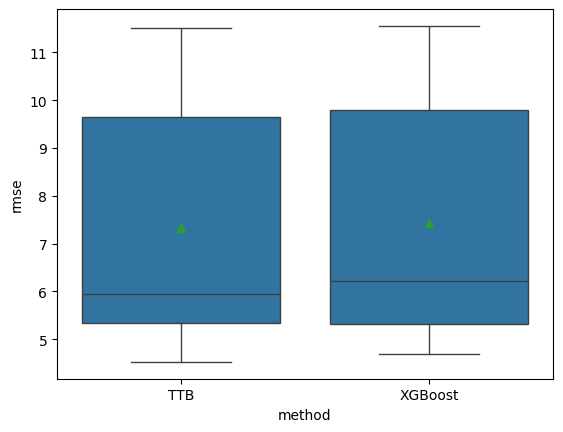

In [26]:


dat = pd.read_csv(f'results/ttb_LS_500.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb_500.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, lk = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [27]:
best_params_for_us

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
697,0.1,2.0,1.0,0.0,0.5,7.321768,4.855935,10,859.0,400.0,4.793880,3.658037,5.055593,3.836138,TransferTreeBoost
57,0.1,2.0,1.0,0.0,0.5,7.321768,4.855935,10,850.0,400.0,10.106357,5.645412,10.417481,5.349474,TransferTreeBoost
582,0.1,2.0,1.0,0.0,0.5,7.321768,4.855935,10,858.0,400.0,5.052236,4.073704,5.280193,4.028558,TransferTreeBoost
97,0.1,2.0,1.0,0.0,0.5,7.321768,4.855935,10,851.0,400.0,5.296607,4.256179,9.771564,5.693055,TransferTreeBoost
521,0.1,2.0,1.0,0.0,0.5,7.321768,4.855935,10,857.0,400.0,4.882106,3.929191,11.522056,6.791164,TransferTreeBoost
473,0.1,2.0,1.0,0.0,0.5,7.321768,4.855935,10,856.0,400.0,5.376187,4.343467,9.256872,5.844450,TransferTreeBoost
257,0.1,2.0,1.0,0.0,0.5,7.321768,4.855935,10,853.0,400.0,9.553489,4.723050,5.502401,4.434713,TransferTreeBoost
369,0.1,2.0,1.0,0.0,0.5,7.321768,4.855935,10,855.0,400.0,10.750424,6.491308,5.556106,4.228834,TransferTreeBoost
185,0.1,2.0,1.0,0.0,0.5,7.321768,4.855935,10,852.0,400.0,6.952858,5.460247,6.330295,4.470898,TransferTreeBoost
310,0.1,2.0,1.0,0.0,0.5,7.321768,4.855935,10,854.0,400.0,6.350546,4.929075,4.525124,3.882070,TransferTreeBoost


In [28]:
lk

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
0,0.1,1.0,7.428562,4.991892,10,0,850.0,10.289880,5.798631,10.510426,5.626100,XGBoost
6,0.1,1.0,7.428562,4.991892,10,6,851.0,5.281494,4.156021,9.963313,5.760010,XGBoost
12,0.1,1.0,7.428562,4.991892,10,12,852.0,6.021972,4.719320,6.627472,4.783662,XGBoost
18,0.1,1.0,7.428562,4.991892,10,18,853.0,9.758301,4.846197,5.715502,4.462940,XGBoost
24,0.1,1.0,7.428562,4.991892,10,24,854.0,6.289599,4.920769,4.682289,4.056369,XGBoost
30,0.1,1.0,7.428562,4.991892,10,30,855.0,10.752857,6.522272,5.815330,4.627122,XGBoost
42,0.1,1.0,7.428562,4.991892,10,42,857.0,4.691513,3.876138,11.555110,6.782545,XGBoost
36,0.1,1.0,7.428562,4.991892,10,36,856.0,5.004069,4.072625,9.268310,6.000839,XGBoost
48,0.1,1.0,7.428562,4.991892,10,48,858.0,4.766570,3.915629,5.187943,3.922789,XGBoost
54,0.1,1.0,7.428562,4.991892,10,54,859.0,4.848450,3.793390,4.959927,3.896540,XGBoost
